<a href="https://colab.research.google.com/github/quintanamarquezraudel-cloud/facebook-ads-roi-tecnocool/blob/main/facebook_ads_roi_TecnoCool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduccion

TecnoCool es una tienda de tecnología que invierte en campañas de Facebook Ads segmentadas por edad, género e intereses, pero no sabe qué combinación de audiencia le da mejor retorno.

Se me pidió analizar los datos históricos de campañas para identificar qué segmentos generan mejor ROI y así optimizar el presupuesto publicitario.

## Informacion General

In [ ]:
#Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Cargar base de datos
tecnocool = pd.read_csv('tecnocool.csv')

In [ ]:
#Imprimiendo las primeras filas del DataFrame
tecnocool.head()

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
0,708746,17/08/2017,17/08/2017,916,103916,30-34,M,15,17,17,7350.0,1,1.43,2.0,1.0
1,708749,17/08/2017,17/08/2017,916,103917,30-34,M,16,19,21,17861.0,2,1.82,2.0,0.0
2,708771,17/08/2017,17/08/2017,916,103920,30-34,M,20,25,22,693.0,0,0.00,1.0,0.0
3,708815,30/08/2017,30/08/2017,916,103928,30-34,M,28,32,32,4259.0,1,1.25,1.0,0.0
4,708818,17/08/2017,17/08/2017,916,103928,30-34,M,28,33,32,4133.0,1,1.29,1.0,1.0


In [ ]:
#Imprimir la informacion general del DataFrame
tecnocool.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   reporting_start      1143 non-null   object 
 2   reporting_end        1143 non-null   object 
 3   campaign_id          1143 non-null   object 
 4   fb_campaign_id       1143 non-null   object 
 5   age                  1143 non-null   object 
 6   gender               1143 non-null   object 
 7   interest1            1143 non-null   int64  
 8   interest2            1143 non-null   int64  
 9   interest3            1143 non-null   int64  
 10  impressions          1143 non-null   float64
 11  clicks               1143 non-null   int64  
 12  spent                1143 non-null   float64
 13  total_conversion     761 non-null    float64
 14  approved_conversion  761 non-null    float64
dtypes: float64(4), int64(5), object(6)
mem

In [ ]:
# Mostrando datos estadísticos del DataFrame
tecnocool.describe()

,ad_id,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
count,1.143000e+03,1143.000000,1.143000e+03,1143.000000,1.143000e+03,1143.000000,1143.000000,761.000000,761.000000
mean,9.872611e+05,33.884514,1.180606e+05,42.474191,6.872500e+04,11.629921,17.597760,2.161629,0.768725
std,1.939928e+05,27.560263,2.670506e+05,48.987248,2.067023e+05,27.347899,48.418711,4.062201,1.656445
min,7.087460e+05,2.000000,3.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,7.776325e+05,16.000000,2.200000e+01,19.000000,1.442650e+02,1.000000,0.000000,1.000000,0.000000
50%,1.121185e+06,26.000000,3.300000e+01,27.000000,3.142000e+03,2.000000,1.530000,1.000000,0.000000
75%,1.121804e+06,32.000000,9.889400e+04,38.000000,2.786400e+04,8.000000,8.540000,2.000000,1.000000
max,1.314415e+06,120.000000,2.286228e+06,421.000000,3.052003e+06,340.000000,639.949998,60.000000,21.000000


### Hallazgos

*   Las columnas reporting_start y reporting_end estan en formato object (texto) en lugar de fechas.

*   Se detectaron filas con valores en cero en clicks y approved_conversion, lo cual generará valores NaN al calcular métricas como CPC y costo por conversión aprobada (división entre cero). Se decidió conservar estos valores como NaN en lugar de reemplazarlos por cero, ya que representan casos donde la métrica no aplica, evitando así distorsionar los promedios por segmento.

*   Se detectaron valores nulos en las columnas total_conversions y approved_conversion.








## Preprocesamiento de datos

### Corrección de la desalineación de columnas

Al explorar los valores nulos en total_conversion y approved_conversion, se planteó la hipótesis de que las columnas estaban recorridas a partir de cierta fila. A continuación se investiga esta hipótesis: si se confirma, se corregirá el corrimiento; si los datos resultan corruptos sin un patrón claro, esas filas se descartarán del análisis.

In [ ]:
# Filtré las filas donde total_conversion tiene valores nulos
tecnocool[tecnocool['total_conversion'].isnull()]

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
761,1121594,26/08/2017,26/08/2017,45-49,M,10,14,14,426500,72,128.279999,4,1.0,NaN,NaN
762,1121597,30/08/2017,30/08/2017,45-49,M,15,21,19,54237,7,10.780000,2,1.0,NaN,NaN
763,1121598,30/08/2017,30/08/2017,45-49,M,15,19,18,506916,89,133.699999,2,2.0,NaN,NaN
764,1121599,30/08/2017,30/08/2017,45-49,M,15,17,18,250960,42,64.880000,2,0.0,NaN,NaN
765,1121601,30/08/2017,30/08/2017,45-49,M,16,20,18,2286228,353,603.380002,16,7.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,1314410,19/08/2017,19/08/2017,45-49,F,109,111,114,1129773,252,358.189997,13,2.0,NaN,NaN
1139,1314411,19/08/2017,19/08/2017,45-49,F,110,111,116,637549,120,173.880003,3,0.0,NaN,NaN
1140,1314412,19/08/2017,19/08/2017,45-49,F,111,113,117,151531,28,40.289999,2,0.0,NaN,NaN
1141,1314414,17/08/2017,17/08/2017,45-49,F,113,114,117,790253,135,198.710001,8,2.0,NaN,NaN


In [ ]:
# Revisé valores únicos de la columna 'age' para confirmar el corrimiento de columnas
tecnocool["age"].unique()

array(['30-34', '35-39', '40-44', '45-49', '10', '15', '16', '18', '19',
       '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '31',
       '32', '36', '63', '64', '65', '2', '66', '30', '7', '100', '101',
       '102', '103', '105', '107', '110', '111', '112', '113', '108',
       '109', '114', '104', '106'], dtype=object)

In [ ]:
# Revisé valores únicos de la columna 'gender' para confirmar el corriemiento de columnas
tecnocool["gender"].unique()

array(['M', 'F', '14', '21', '19', '17', '20', '22', '24', '25', '23',
       '26', '27', '28', '29', '30', '33', '31', '32', '34', '35', '36',
       '37', '38', '68', '64', '65', '69', '67', '5', '71', '13', '18',
       '66', '8', '6', '10', '72', '15', '16', '70', '4', '9', '12', '41',
       '11', '106', '104', '107', '108', '112', '117', '116', '105',
       '110', '113', '114', '109', '115', '102', '103', '111', '118'],
      dtype=object)

In [ ]:
# Verifiqué en qué filas 'gender' tiene valores M o F, para confirmar desde que fila se corrieron las columnas
tecnocool[tecnocool['gender'].isin(['M', 'F'])]

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
0,708746,17/08/2017,17/08/2017,916,103916,30-34,M,15,17,17,7350.0,1,1.430000,2.0,1.0
1,708749,17/08/2017,17/08/2017,916,103917,30-34,M,16,19,21,17861.0,2,1.820000,2.0,0.0
2,708771,17/08/2017,17/08/2017,916,103920,30-34,M,20,25,22,693.0,0,0.000000,1.0,0.0
3,708815,30/08/2017,30/08/2017,916,103928,30-34,M,28,32,32,4259.0,1,1.250000,1.0,0.0
4,708818,17/08/2017,17/08/2017,916,103928,30-34,M,28,33,32,4133.0,1,1.290000,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
756,1121585,20/08/2017,20/08/2017,1178,144621,40-44,M,66,72,68,9773.0,1,1.460000,1.0,0.0
757,1121589,20/08/2017,20/08/2017,1178,144622,45-49,M,10,16,11,464036.0,77,123.550000,3.0,1.0
758,1121590,20/08/2017,20/08/2017,1178,144622,45-49,M,10,16,15,478480.0,75,135.750001,3.0,1.0
759,1121592,20/08/2017,20/08/2017,1178,144622,45-49,M,10,14,11,428812.0,66,116.880000,4.0,2.0


In [ ]:
# Dividiendo el DataFrame apartir de la fila donde se detectarón las columnas desalineadas (recorridas)

# Parte 1: desde el inicio hasta la fila 761
tecnocool1 = tecnocool.iloc[:761]

# Parte 2: desde la fila 761 en adelante
tecnocool2 = tecnocool.iloc[761:]

In [ ]:
# mostrando las primeras filas del DataFrame 'tecnocool1'
tecnocool1.head()

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
0,708746,17/08/2017,17/08/2017,916,103916,30-34,M,15,17,17,7350.0,1,1.43,2.0,1.0
1,708749,17/08/2017,17/08/2017,916,103917,30-34,M,16,19,21,17861.0,2,1.82,2.0,0.0
2,708771,17/08/2017,17/08/2017,916,103920,30-34,M,20,25,22,693.0,0,0.00,1.0,0.0
3,708815,30/08/2017,30/08/2017,916,103928,30-34,M,28,32,32,4259.0,1,1.25,1.0,0.0
4,708818,17/08/2017,17/08/2017,916,103928,30-34,M,28,33,32,4133.0,1,1.29,1.0,1.0


In [ ]:
# mostrando las ultimas filas del DataFrame 'tecnocool1'
tecnocool1.tail()

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
756,1121585,20/08/2017,20/08/2017,1178,144621,40-44,M,66,72,68,9773.0,1,1.460000,1.0,0.0
757,1121589,20/08/2017,20/08/2017,1178,144622,45-49,M,10,16,11,464036.0,77,123.550000,3.0,1.0
758,1121590,20/08/2017,20/08/2017,1178,144622,45-49,M,10,16,15,478480.0,75,135.750001,3.0,1.0
759,1121592,20/08/2017,20/08/2017,1178,144622,45-49,M,10,14,11,428812.0,66,116.880000,4.0,2.0
760,1121593,26/08/2017,26/08/2017,1178,144622,45-49,M,10,16,16,1177535.0,221,365.660001,15.0,3.0


In [ ]:
# mostrando las primeras filas del DataFrame 'tecnocool2'
tecnocool2.head()

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
761,1121594,26/08/2017,26/08/2017,45-49,M,10,14,14,426500,72,128.279999,4,1.0,NaN,NaN
762,1121597,30/08/2017,30/08/2017,45-49,M,15,21,19,54237,7,10.780000,2,1.0,NaN,NaN
763,1121598,30/08/2017,30/08/2017,45-49,M,15,19,18,506916,89,133.699999,2,2.0,NaN,NaN
764,1121599,30/08/2017,30/08/2017,45-49,M,15,17,18,250960,42,64.880000,2,0.0,NaN,NaN
765,1121601,30/08/2017,30/08/2017,45-49,M,16,20,18,2286228,353,603.380002,16,7.0,NaN,NaN


In [ ]:
# mostrando las ultimas filas del DataFrame 'tecnocool2'
tecnocool2.tail()

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
1138,1314410,19/08/2017,19/08/2017,45-49,F,109,111,114,1129773,252,358.189997,13,2.0,NaN,NaN
1139,1314411,19/08/2017,19/08/2017,45-49,F,110,111,116,637549,120,173.880003,3,0.0,NaN,NaN
1140,1314412,19/08/2017,19/08/2017,45-49,F,111,113,117,151531,28,40.289999,2,0.0,NaN,NaN
1141,1314414,17/08/2017,17/08/2017,45-49,F,113,114,117,790253,135,198.710001,8,2.0,NaN,NaN
1142,1314415,17/08/2017,17/08/2017,45-49,F,114,116,118,513161,114,165.609999,5,2.0,NaN,NaN


In [ ]:
# Comprobando el corrimiento de columnas mediante valores únicos de campaign_id.
tecnocool2["campaign_id"].unique()

array(['45-49', '30-34', '35-39', '40-44'], dtype=object)

In [ ]:
# Comprobando el corrimiento de columnas mediante valores únicos de fb_campaign_id.
tecnocool2["fb_campaign_id"].unique()

array(['M', 'F'], dtype=object)

In [ ]:
# Revisando los tipos de dato de 'tecnocool2' antes de renombrar las columnas
tecnocool2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 761 to 1142
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                382 non-null    int64  
 1   reporting_start      382 non-null    object 
 2   reporting_end        382 non-null    object 
 3   campaign_id          382 non-null    object 
 4   fb_campaign_id       382 non-null    object 
 5   age                  382 non-null    object 
 6   gender               382 non-null    object 
 7   interest1            382 non-null    int64  
 8   interest2            382 non-null    int64  
 9   interest3            382 non-null    int64  
 10  impressions          382 non-null    float64
 11  clicks               382 non-null    int64  
 12  spent                382 non-null    float64
 13  total_conversion     0 non-null      float64
 14  approved_conversion  0 non-null      float64
dtypes: float64(4), int64(5), object(6)
me

In [ ]:
# Renombrando columnas de 'tecnocool2' para corregir el corrimiento detectado
tecnocool2.columns = ['ad_id', 'reporting_start', 'reporting_end', 'age', 'gender', 'interest1', 'interest2', 'interest3', 'impressions', 'clicks', 'spent', 'total_conversion', 'approved_conversion', 'campaign_id', 'fb_campaign_id']

In [ ]:
# Revisando los tipos de dato de 'tecnocool2' después de renombrar las columnas
tecnocool2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 761 to 1142
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                382 non-null    int64  
 1   reporting_start      382 non-null    object 
 2   reporting_end        382 non-null    object 
 3   age                  382 non-null    object 
 4   gender               382 non-null    object 
 5   interest1            382 non-null    object 
 6   interest2            382 non-null    object 
 7   interest3            382 non-null    int64  
 8   impressions          382 non-null    int64  
 9   clicks               382 non-null    int64  
 10  spent                382 non-null    float64
 11  total_conversion     382 non-null    int64  
 12  approved_conversion  382 non-null    float64
 13  campaign_id          0 non-null      float64
 14  fb_campaign_id       0 non-null      float64
dtypes: float64(4), int64(5), object(6)
me

In [ ]:
# Ajustando los tipos de dato de 'tecnocool2' para que coincidan con 'tecnocool1'
tecnocool2["campaign_id"] = tecnocool2["campaign_id"].astype("object")
tecnocool2["fb_campaign_id"] = tecnocool2["fb_campaign_id"].astype("object")
tecnocool2['interest1'] = tecnocool2['interest1'].astype('int')
tecnocool2['interest2'] = tecnocool2['interest2'].astype('int')
tecnocool2['impressions'] = tecnocool2['impressions'].astype('float')
tecnocool2['total_conversion'] = tecnocool2['total_conversion'].astype('float')

/tmp/ipykernel_18860/3460483431.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tecnocool2["campaign_id"] = tecnocool2["campaign_id"].astype("object")
/tmp/ipykernel_18860/3460483431.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tecnocool2["fb_campaign_id"] = tecnocool2["fb_campaign_id"].astype("object")
/tmp/ipykernel_18860/3460483431.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

In [ ]:
# Comprobando que las columnas quedaron correctamente tras el renombramiento
tecnocool2.head()

,ad_id,reporting_start,reporting_end,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion,campaign_id,fb_campaign_id
761,1121594,26/08/2017,26/08/2017,45-49,M,10,14,14,426500.0,72,128.279999,4.0,1.0,NaN,NaN
762,1121597,30/08/2017,30/08/2017,45-49,M,15,21,19,54237.0,7,10.780000,2.0,1.0,NaN,NaN
763,1121598,30/08/2017,30/08/2017,45-49,M,15,19,18,506916.0,89,133.699999,2.0,2.0,NaN,NaN
764,1121599,30/08/2017,30/08/2017,45-49,M,15,17,18,250960.0,42,64.880000,2.0,0.0,NaN,NaN
765,1121601,30/08/2017,30/08/2017,45-49,M,16,20,18,2286228.0,353,603.380002,16.0,7.0,NaN,NaN


In [ ]:
# Uniendo tecnocool1 y tecnocool2 en un solo dataframe corregido
tecnocoolcorregido = pd.concat([tecnocool1, tecnocool2], ignore_index=True)

# Comprobando con las primeras filas que 'tecnocoolcorregido' quedó correctamente alineado
tecnocoolcorregido.head()

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
0,708746,17/08/2017,17/08/2017,916,103916,30-34,M,15,17,17,7350.0,1,1.43,2.0,1.0
1,708749,17/08/2017,17/08/2017,916,103917,30-34,M,16,19,21,17861.0,2,1.82,2.0,0.0
2,708771,17/08/2017,17/08/2017,916,103920,30-34,M,20,25,22,693.0,0,0.00,1.0,0.0
3,708815,30/08/2017,30/08/2017,916,103928,30-34,M,28,32,32,4259.0,1,1.25,1.0,0.0
4,708818,17/08/2017,17/08/2017,916,103928,30-34,M,28,33,32,4133.0,1,1.29,1.0,1.0


In [ ]:
# Comprobando con las últimas filas que 'tecnocoolcorregido' quedó correctamente alineado
tecnocoolcorregido.tail()

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
1138,1314410,19/08/2017,19/08/2017,NaN,NaN,45-49,F,109,111,114,1129773.0,252,358.189997,13.0,2.0
1139,1314411,19/08/2017,19/08/2017,NaN,NaN,45-49,F,110,111,116,637549.0,120,173.880003,3.0,0.0
1140,1314412,19/08/2017,19/08/2017,NaN,NaN,45-49,F,111,113,117,151531.0,28,40.289999,2.0,0.0
1141,1314414,17/08/2017,17/08/2017,NaN,NaN,45-49,F,113,114,117,790253.0,135,198.710001,8.0,2.0
1142,1314415,17/08/2017,17/08/2017,NaN,NaN,45-49,F,114,116,118,513161.0,114,165.609999,5.0,2.0


#### Hallazgos

Se detectó que a partir de la fila 761 los datos estaban recorridos dos posiciones hacia la izquierda respecto a sus columnas originales, dejando sin datos reales a total_conversion y approved_conversion. Se corrigió separando el dataframe en dos partes, renombrando las columnas de la segunda parte según el corrimiento detectado, ajustando los tipos de dato de "tecnocool2" para que coincidieran con "tecnocool1", y uniéndolas de nuevo en un solo dataframe corregido.

### Eliminación de espacios en blanco

In [ ]:
# Revisando qué columnas son de tipo object
tecnocoolcorregido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   reporting_start      1143 non-null   object 
 2   reporting_end        1143 non-null   object 
 3   campaign_id          761 non-null    object 
 4   fb_campaign_id       761 non-null    object 
 5   age                  1143 non-null   object 
 6   gender               1143 non-null   object 
 7   interest1            1143 non-null   int64  
 8   interest2            1143 non-null   int64  
 9   interest3            1143 non-null   int64  
 10  impressions          1143 non-null   float64
 11  clicks               1143 non-null   int64  
 12  spent                1143 non-null   float64
 13  total_conversion     1143 non-null   float64
 14  approved_conversion  1143 non-null   float64
dtypes: float64(4), int64(5), object(6)
mem

Se revisan las columnas de tipo texto en busca de espacios en blanco ocultos que pudieran causar inconsistencias.

In [ ]:
# Verificando valores únicos a las columnas object antes de eliminar espacios en blanco

for column in tecnocoolcorregido.select_dtypes(include='object').columns:
  if column != 'fb_campaign_id':
    print(f'Verificando espacios en blanco de {column}: {tecnocoolcorregido[column].unique()}')



Verificando espacios en blanco de reporting_start: ['17/08/2017' '30/08/2017' '29/08/2017' '18/08/2017' '19/08/2017'
 '27/08/2017' '26/08/2017' '25/08/2017' '28/08/2017' '20/08/2017'
 '21/08/2017' '24/08/2017' '23/08/2017' '22/08/2017']
Verificando espacios en blanco de reporting_end: ['17/08/2017' '30/08/2017' '29/08/2017' '18/08/2017' '19/08/2017'
 '27/08/2017' '26/08/2017' '25/08/2017' '28/08/2017' '20/08/2017'
 '21/08/2017' '24/08/2017' '23/08/2017' '22/08/2017']
Verificando espacios en blanco de campaign_id: ['916' '936' '1178' nan]
Verificando espacios en blanco de age: ['30-34' '35-39' '40-44' '45-49']
Verificando espacios en blanco de gender: ['M' 'F']


#### Hallazgos

Se verificaron las columnas de tipo texto y no se encontraron espacios en blanco ocultos, por lo que no fue necesario aplicar limpieza adicional.

### Detección de valores ausentes

In [ ]:
# Detecatando valores ausentes
tecnocoolcorregido.isnull().sum()

,0
ad_id,0
reporting_start,0
reporting_end,0
campaign_id,382
fb_campaign_id,382
age,0
gender,0
interest1,0
interest2,0
interest3,0


#### Hallazgos

Se detectaron valores ausentes únicamente en las columnas 'campaign_id' y 'fb_campaign_id', correspondientes a datos que se perdieron durante el corrimiento de columnas. Dado que estos IDs no son relevantes para el análisis de ROI y optimización de campañas, se ignorarán sin necesidad de eliminarlos.



### Detección de duplicados

In [ ]:
# Identificando duplicados explícitos
tecnocoolcorregido.duplicated().sum()

np.int64(0)

In [ ]:
# Identificando duplicados implícitos en las columnas 'age' y 'gender', por ser las más propensas a inconsistencias de escritura
col_cat = ['age', 'gender']
for column in col_cat:
    print(f'Duplicados implícitos en {column}: {tecnocoolcorregido[column].unique()}')


Duplicados implícitos en age: ['30-34' '35-39' '40-44' '45-49']
Duplicados implícitos en gender: ['M' 'F']


#### Hallazgos

No se encontraron valores duplicados, ni implícitos ni explícitos

### Detección de valores negativos y atípicos

In [ ]:
# Verificando si existen valores negativos y atípicos
tecnocoolcorregido.describe()

,ad_id,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
count,1.143000e+03,1143.000000,1143.000000,1143.000000,1.143000e+03,1143.000000,1143.000000,1143.000000,1143.000000
mean,9.872611e+05,32.766404,36.245844,36.222222,1.867321e+05,33.390201,51.360656,2.855643,0.944007
std,1.939928e+05,26.952131,26.937853,26.924679,3.127622e+05,56.892438,86.908418,4.483593,1.737708
min,7.087460e+05,2.000000,3.000000,3.000000,8.700000e+01,0.000000,0.000000,0.000000,0.000000
25%,7.776325e+05,16.000000,20.000000,20.000000,6.503500e+03,1.000000,1.480000,1.000000,0.000000
50%,1.121185e+06,25.000000,28.000000,28.000000,5.150900e+04,8.000000,12.370000,1.000000,1.000000
75%,1.121804e+06,31.000000,35.000000,35.000000,2.217690e+05,37.500000,60.025000,3.000000,1.000000
max,1.314415e+06,114.000000,118.000000,120.000000,3.052003e+06,421.000000,639.949998,60.000000,21.000000


#### Hallazgos

No se detectaron valores negativos ni valores atípicos fuera de un rango razonable.

### Tipos y optimización de datos

In [ ]:
# Visualizando el tipo de dato de cada columna
tecnocoolcorregido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   reporting_start      1143 non-null   object 
 2   reporting_end        1143 non-null   object 
 3   campaign_id          761 non-null    object 
 4   fb_campaign_id       761 non-null    object 
 5   age                  1143 non-null   object 
 6   gender               1143 non-null   object 
 7   interest1            1143 non-null   int64  
 8   interest2            1143 non-null   int64  
 9   interest3            1143 non-null   int64  
 10  impressions          1143 non-null   float64
 11  clicks               1143 non-null   int64  
 12  spent                1143 non-null   float64
 13  total_conversion     1143 non-null   float64
 14  approved_conversion  1143 non-null   float64
dtypes: float64(4), int64(5), object(6)
mem

In [ ]:

# Se convirtió reporting_start a tipo fecha (datetime) indicando que el día va primero
tecnocoolcorregido["reporting_start"] = pd.to_datetime(tecnocoolcorregido["reporting_start"], errors="coerce", dayfirst=True)

# Se convirtió reporting_end a tipo fecha (datetime) indicando que el día va primero
tecnocoolcorregido["reporting_end"] = pd.to_datetime(tecnocoolcorregido["reporting_end"], errors="coerce", dayfirst=True)

# Verificando el tipo de dato a fecha de las columnas 'reporting_start' y 'reporting_end'
tecnocoolcorregido[["reporting_start", "reporting_end"]].dtypes

,0
reporting_start,datetime64[ns]
reporting_end,datetime64[ns]


In [ ]:
# Convirtiendo las columnas 'age' y 'gender' a tipo category para optimizar memoria
tecnocoolcorregido["age"] = tecnocoolcorregido["age"].astype("category")
tecnocoolcorregido["gender"] = tecnocoolcorregido["gender"].astype("category")

# Verificando que las columnas hayan quedado correctamente como datetime y category
tecnocoolcorregido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ad_id                1143 non-null   int64         
 1   reporting_start      1143 non-null   datetime64[ns]
 2   reporting_end        1143 non-null   datetime64[ns]
 3   campaign_id          761 non-null    object        
 4   fb_campaign_id       761 non-null    object        
 5   age                  1143 non-null   category      
 6   gender               1143 non-null   category      
 7   interest1            1143 non-null   int64         
 8   interest2            1143 non-null   int64         
 9   interest3            1143 non-null   int64         
 10  impressions          1143 non-null   float64       
 11  clicks               1143 non-null   int64         
 12  spent                1143 non-null   float64       
 13  total_conversion     1143 non-nul

### Conclusión general de procesamiento de datos

- Se corrigió un corrimiento de columnas detectado en "tecnocool2".

- Se unificaron los tipos de dato entre "tecnocool1" y "tecnocool2" antes de concatenarlos.

- Se verificaron las columnas de texto y no se encontraron espacios en blanco ocultos.

- No se detectaron duplicados explícitos ni implícitos, prestando especial atención a "age" y "gender".

- No se detectaron valores negativos ni atípicos fuera de un rango razonable.

- Se convirtieron "reporting_start" y "reporting_end" a tipo datetime.

- Se convirtieron "age" y "gender" a tipo category para optimizar el uso de memoria y facilitar el análisis posterior.


## Análisis exploratorio de datos (EDA)



In [ ]:
# Obteniendo información general del DataFrame
tecnocoolcorregido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ad_id                1143 non-null   int64         
 1   reporting_start      1143 non-null   datetime64[ns]
 2   reporting_end        1143 non-null   datetime64[ns]
 3   campaign_id          761 non-null    object        
 4   fb_campaign_id       761 non-null    object        
 5   age                  1143 non-null   category      
 6   gender               1143 non-null   category      
 7   interest1            1143 non-null   int64         
 8   interest2            1143 non-null   int64         
 9   interest3            1143 non-null   int64         
 10  impressions          1143 non-null   float64       
 11  clicks               1143 non-null   int64         
 12  spent                1143 non-null   float64       
 13  total_conversion     1143 non-nul

In [ ]:
# Obteniendo estadísticas descriptivas del dataframe para identificar rangos, promedios y posibles valores atípicos
tecnocoolcorregido.describe()

,ad_id,reporting_start,reporting_end,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
count,1.143000e+03,1143,1143,1143.000000,1143.000000,1143.000000,1.143000e+03,1143.000000,1143.000000,1143.000000,1143.000000
mean,9.872611e+05,2017-08-23 00:26:27.401574912,2017-08-23 00:26:27.401574912,32.766404,36.245844,36.222222,1.867321e+05,33.390201,51.360656,2.855643,0.944007
min,7.087460e+05,2017-08-17 00:00:00,2017-08-17 00:00:00,2.000000,3.000000,3.000000,8.700000e+01,0.000000,0.000000,0.000000,0.000000
25%,7.776325e+05,2017-08-20 00:00:00,2017-08-20 00:00:00,16.000000,20.000000,20.000000,6.503500e+03,1.000000,1.480000,1.000000,0.000000
50%,1.121185e+06,2017-08-23 00:00:00,2017-08-23 00:00:00,25.000000,28.000000,28.000000,5.150900e+04,8.000000,12.370000,1.000000,1.000000
75%,1.121804e+06,2017-08-26 00:00:00,2017-08-26 00:00:00,31.000000,35.000000,35.000000,2.217690e+05,37.500000,60.025000,3.000000,1.000000
max,1.314415e+06,2017-08-30 00:00:00,2017-08-30 00:00:00,114.000000,118.000000,120.000000,3.052003e+06,421.000000,639.949998,60.000000,21.000000
std,1.939928e+05,NaN,NaN,26.952131,26.937853,26.924679,3.127622e+05,56.892438,86.908418,4.483593,1.737708


In [ ]:
# Mostrando distribución de edades
tecnocoolcorregido['age'].value_counts()

,count
age,
30-34,426
45-49,259
35-39,248
40-44,210


In [ ]:
# Mostrandos distribución de genero
tecnocoolcorregido['gender'].value_counts()

,count
gender,
M,592
F,551


### Conclusión general de (EDA)


Se identificaron valores ausentes en las columnas campaign_id y fb_campaign_id, resultado del corrimiento de columnas detectado anteriormente. Se decidió conservarlos sin modificar, ya que estas columnas no son relevantes para el análisis de ROI.

En promedio, las campañas generan 186,732 impresiones, 33.39 clics y un gasto de \$51.36, con 2.85 conversiones totales y 0.94 conversiones aprobadas. Sin embargo, se observan máximos muy superiores a la media en todas las columnas (hasta 3,052,003 impresiones, 421 clics, $639.94 de gasto, 60 conversiones totales y 21 aprobadas), lo que indica la presencia de campañas atípicas con desempeño mucho más alto que el resto.

En cuanto a la distribución demográfica, el grupo de edad más numeroso es 30-34 años (426 registros), seguido de 45-49 (259), 35-39 (248) y 40-44 (210). Respecto al género, la muestra está bastante balanceada, con 592 registros masculinos y 551 femeninos.






## Cálculo de métricas de rendimiento (CTR, CPC, costo por conversión aprobada y tasa de conversión)

En esta sección se calculan las principales métricas de rendimiento publicitario: CTR (tasa de clics), CPC (costo por clic), costo por conversión aprobada y tasa de conversión, que permiten evaluar la eficiencia de las campañas.

In [ ]:
# Mostrando la columna calculada 'CTR'
tecnocoolcorregido['ctr'] = (tecnocoolcorregido['clicks'] / tecnocoolcorregido['impressions']) * 100
tecnocoolcorregido.head()

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion,ctr
0,708746,2017-08-17,2017-08-17,916,103916,30-34,M,15,17,17,7350.0,1,1.43,2.0,1.0,0.013605
1,708749,2017-08-17,2017-08-17,916,103917,30-34,M,16,19,21,17861.0,2,1.82,2.0,0.0,0.011198
2,708771,2017-08-17,2017-08-17,916,103920,30-34,M,20,25,22,693.0,0,0.00,1.0,0.0,0.000000
3,708815,2017-08-30,2017-08-30,916,103928,30-34,M,28,32,32,4259.0,1,1.25,1.0,0.0,0.023480
4,708818,2017-08-17,2017-08-17,916,103928,30-34,M,28,33,32,4133.0,1,1.29,1.0,1.0,0.024195


In [ ]:
# Mostrando la columna calculada 'CPC'
tecnocoolcorregido['cpc'] = tecnocoolcorregido['spent'] / tecnocoolcorregido['clicks']
tecnocoolcorregido.head()

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion,ctr,cpc
0,708746,2017-08-17,2017-08-17,916,103916,30-34,M,15,17,17,7350.0,1,1.43,2.0,1.0,0.013605,1.43
1,708749,2017-08-17,2017-08-17,916,103917,30-34,M,16,19,21,17861.0,2,1.82,2.0,0.0,0.011198,0.91
2,708771,2017-08-17,2017-08-17,916,103920,30-34,M,20,25,22,693.0,0,0.00,1.0,0.0,0.000000,NaN
3,708815,2017-08-30,2017-08-30,916,103928,30-34,M,28,32,32,4259.0,1,1.25,1.0,0.0,0.023480,1.25
4,708818,2017-08-17,2017-08-17,916,103928,30-34,M,28,33,32,4133.0,1,1.29,1.0,1.0,0.024195,1.29


In [ ]:
# Mostrando la columna calculada 'costo_por_conversion_aprovada'
tecnocoolcorregido['costo_por_conversion_aprobada'] = tecnocoolcorregido['spent'] / tecnocoolcorregido['approved_conversion']
tecnocoolcorregido.head()

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion,ctr,cpc,costo_por_conversion_aprobada
0,708746,2017-08-17,2017-08-17,916,103916,30-34,M,15,17,17,7350.0,1,1.43,2.0,1.0,0.013605,1.43,1.43
1,708749,2017-08-17,2017-08-17,916,103917,30-34,M,16,19,21,17861.0,2,1.82,2.0,0.0,0.011198,0.91,inf
2,708771,2017-08-17,2017-08-17,916,103920,30-34,M,20,25,22,693.0,0,0.00,1.0,0.0,0.000000,NaN,NaN
3,708815,2017-08-30,2017-08-30,916,103928,30-34,M,28,32,32,4259.0,1,1.25,1.0,0.0,0.023480,1.25,inf
4,708818,2017-08-17,2017-08-17,916,103928,30-34,M,28,33,32,4133.0,1,1.29,1.0,1.0,0.024195,1.29,1.29


Nota: en esta columna pueden aparecer valores NaN (cuando no hubo gasto ni conversiones aprobadas) o inf (cuando hubo gasto pero ninguna conversión fue aprobada, es decir, división entre cero).

In [ ]:
# Mostrando la columna calculada 'tasa_de_conversion'
tecnocoolcorregido['tasa_de_conversion'] = (tecnocoolcorregido['approved_conversion'] / tecnocoolcorregido['clicks']) * 100
tecnocoolcorregido.head()


,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion,ctr,cpc,costo_por_conversion_aprobada,tasa_de_conversion
0,708746,2017-08-17,2017-08-17,916,103916,30-34,M,15,17,17,7350.0,1,1.43,2.0,1.0,0.013605,1.43,1.43,100.0
1,708749,2017-08-17,2017-08-17,916,103917,30-34,M,16,19,21,17861.0,2,1.82,2.0,0.0,0.011198,0.91,inf,0.0
2,708771,2017-08-17,2017-08-17,916,103920,30-34,M,20,25,22,693.0,0,0.00,1.0,0.0,0.000000,NaN,NaN,NaN
3,708815,2017-08-30,2017-08-30,916,103928,30-34,M,28,32,32,4259.0,1,1.25,1.0,0.0,0.023480,1.25,inf,0.0
4,708818,2017-08-17,2017-08-17,916,103928,30-34,M,28,33,32,4133.0,1,1.29,1.0,1.0,0.024195,1.29,1.29,100.0


In [ ]:
# Definiendo las métricas a agrupar por edad y género
metricas = ["ctr", "cpc", "costo_por_conversion_aprobada", "tasa_de_conversion"]

# Reemplazando valores infinitos por NaN para evitar distorsión en los promedios
tecnocoolcorregido[metricas] = tecnocoolcorregido[metricas].replace([np.inf, -np.inf], np.nan)

# Agrupar por edad y género, y calcular promedio
df_grouped = tecnocoolcorregido.groupby(["age", "gender"], observed=True)[metricas].mean().reset_index()

# Mostrando el resultrado agrupado
df_grouped.head()

,age,gender,ctr,cpc,costo_por_conversion_aprobada,tasa_de_conversion
0,30-34,F,0.013547,1.439525,28.666138,14.483368
1,30-34,M,0.009969,1.568945,18.407338,16.341839
2,35-39,F,0.019273,1.418482,48.329580,12.074074
3,35-39,M,0.013890,1.596989,34.297793,12.326594
4,40-44,F,0.022103,1.408659,57.772755,3.945141


### Conclusión general del Calculo de métricas de rendimiento

Se calcularon las 4 métricas de rendimiento por segmento de edad y género. Se detectaron valores infinitos en costo_por_conversión_aprobada y tasa_de_conversion en los casos sin conversiones aprobadas, los cuales se reemplazaron por NaN para evitar distorsionar los promedios.

## Visualización de métricas por edad y género

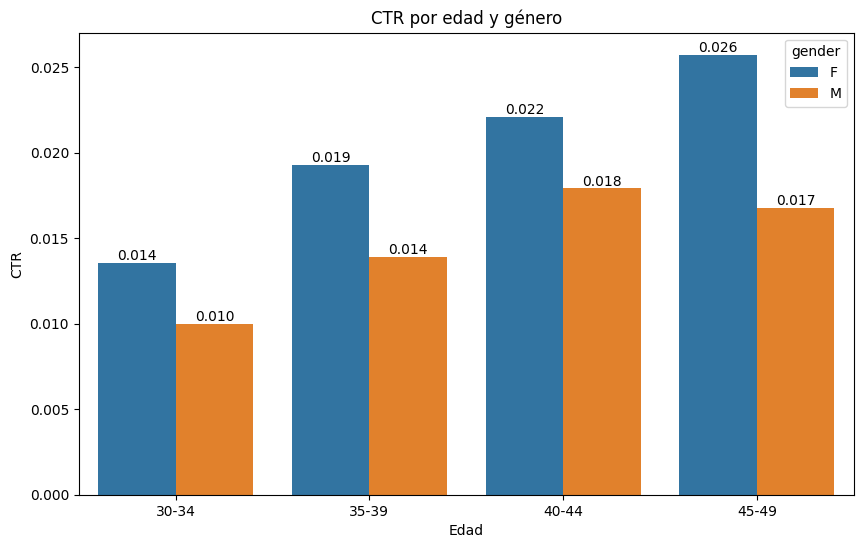

In [ ]:
# Mostrando gráfico de CTR por edad y género
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_grouped, x='age', y='ctr', hue='gender')
plt.title('CTR por edad y género')
plt.xlabel('Edad')
plt.ylabel('CTR')

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.show()

El CTR es más alto en mujeres que en hombres en casi todos los rangos de edad, siendo el grupo de 45-49 años en mujeres el de mejor desempeño (0.026%), mientras que en hombres el pico se da en 40-44 años (0.018%)

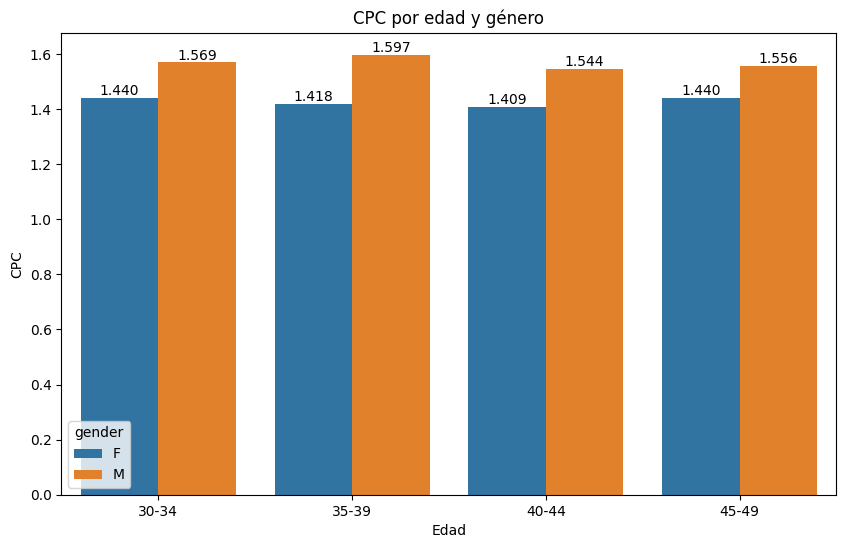

In [ ]:
# Mostrando gráfico de CPC por edad y género
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_grouped, x='age', y='cpc', hue='gender')
plt.title('CPC por edad y género')
plt.xlabel('Edad')
plt.ylabel('CPC')

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.show()


El CPC se mantiene relativamente estable entre los distintos segmentos, oscilando entre 1.40 y 1.60, aunque se observa un patrón consistente donde el género femenino tiene un costo por clic ligeramente menor que el masculino en todos los rangos de edad analizados.

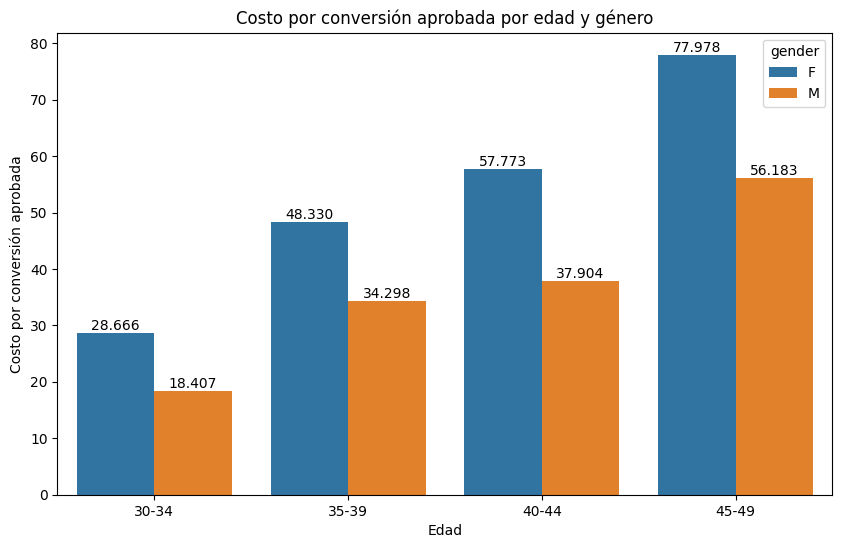

In [ ]:
# Mostrando gráfico de costo_por_conversión_aprobada por edad y género
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_grouped, x='age', y='costo_por_conversion_aprobada', hue='gender')
plt.title('Costo por conversión aprobada por edad y género')
plt.xlabel('Edad')
plt.ylabel('Costo por conversión aprobada')

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.show()

El costo_por_conversión_aprobada aumenta conforme sube la edad en ambos géneros, siendo el rango de 45-49 años el más costoso. Además, el género femenino presenta consistentemente un costo por conversión más alto que el masculino en todos los rangos de edad, contrastando con su mejor desempeño en CTR

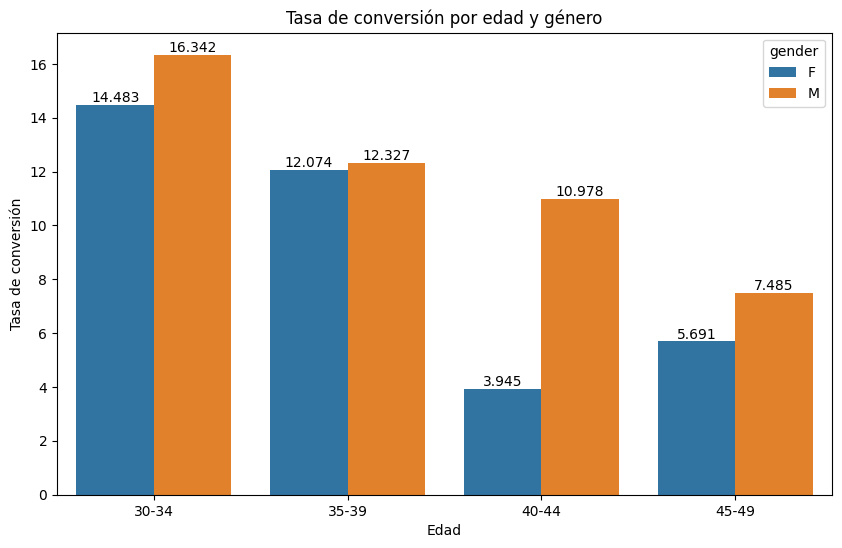

In [ ]:
# Mostrando gráfico de tasa_de_conversión por edad y género
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_grouped, x='age', y='tasa_de_conversion', hue='gender')
plt.title('Tasa de conversión por edad y género')
plt.xlabel('Edad')
plt.ylabel('Tasa de conversión')

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.show()

La tasa de conversión disminuye conforme aumenta la edad en ambos géneros, siendo el rango de 30-34 años el más eficiente (16.34% en masculino, 14.48% en femenino). El género masculino presenta consistentemente una mejor tasa de conversión que el femenino en todos los rangos de edad, siendo el segmento de 30-34 años el que ofrece mejor equilibrio entre costo y conversión.

### Conclusión general de visualización de métricas

Al analizar las métricas de rendimiento por edad y género, se observa que el CTR es más alto en el segmento de 45-49 años, especialmente en mujeres (0.026%), mientras que en hombres el pico se da en 40-44 años (0.018%). El CPC se mantiene relativamente estable entre segmentos (entre 1.40 y 1.60), aunque el género femenino presenta un costo por clic consistentemente menor que el masculino. Sin embargo, el costo por conversión aprobada aumenta con la edad en ambos géneros, siendo el rango de 45-49 años el más costoso (especialmente en mujeres, con 77.98), lo cual contrasta con su buen desempeño en CTR. Por su parte, la tasa de conversión muestra el patrón opuesto: disminuye conforme aumenta la edad, siendo el rango de 30-34 años el más eficiente (16.34% en hombres, 14.48% en mujeres).

En conjunto, estos hallazgos muestran que el segmento de 45-49 años (especialmente femenino) genera más clics pero es más caro de convertir y tiene menor tasa de conversión, mientras que el segmento de 30-34 años (especialmente masculino) es el más eficiente: buena tasa de conversión con el costo por conversión más bajo.

## Conclusión general del proyecto

TecnoCool solicitó analizar sus datos históricos de campañas de Facebook Ads para identificar qué segmentos de audiencia (por edad y género) generan mejor retorno de inversión (ROI) y así optimizar su presupuesto publicitario. Para lograrlo, se realizó un proceso de limpieza y preparación de datos (corrección de un corrimiento de columnas, ajuste de tipos de dato, verificación de duplicados y valores atípicos), seguido del cálculo de métricas clave de rendimiento (CTR, CPC, costo por conversión aprobada y tasa de conversión) segmentadas por edad y género.

Los resultados muestran que el segmento de 30-34 años, especialmente en hombres, ofrece el mejor equilibrio entre costo y conversión, con la tasa de conversión más alta (16.34%) y uno de los costos por conversión más bajos. En contraste, el segmento de 45-49 años, especialmente en mujeres, genera más clics (mejor CTR) pero resulta más caro de convertir y presenta la menor tasa de conversión. Cabe señalar que el grupo de 30-34 años también es el más numeroso en la muestra (426 registros, casi el doble que otros grupos), por lo que su buen desempeño podría estar parcialmente influenciado por el tamaño de la muestra, y se recomendaría validarlo con más datos en el futuro.

En conclusión, el segmento de 30-34 años representa la mejor oportunidad de inversión actual por su eficiencia en conversión, mientras que el segmento de 45-49 años (especialmente mujeres) requiere una revisión más profunda de su estrategia de conversión antes de aumentar su presupuesto.

## Recomendaciones

- Enfocar presupuesto en el rango de 30-34 años, ya que presenta la mejor tasa de conversión y el menor costo por conversión, maximizando el retorno de inversión.
- Ajustar la distribución por género, dando algo más de peso al masculino en los anuncios, ya que convierte mejor y a menor costo en todos los rangos de edad.
- Revisar el mensaje o la oferta para el segmento de 45-49 años (especialmente femenino), ya que genera buen CTR (interés inicial) pero no logra convertir esos clics en compras, lo que sugiere que el problema no es de atracción sino de algo en el proceso posterior al clic.

- Validar estos hallazgos con más datos, dado que el segmento de 30-34 años tiene mayor representación en la muestra actual